In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Hotel room']

In [4]:
df['host_acceptance_rate'].head(20)

47         0.93
61         0.92
74         0.92
99         0.93
134        0.89
157        0.89
158        0.89
169        0.89
213        0.98
402        0.31
717        0.96
939        0.98
951        0.31
953        0.31
1186          1
1708          1
1759       0.89
1905       0.31
2346          1
2907    No data
Name: host_acceptance_rate, dtype: object

In [6]:
df = df[df['host_acceptance_rate'] != 'No data']
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_39244\2432076147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)


C:\Users\issei\AppData\Local\Temp\ipykernel_39244\2668384762.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


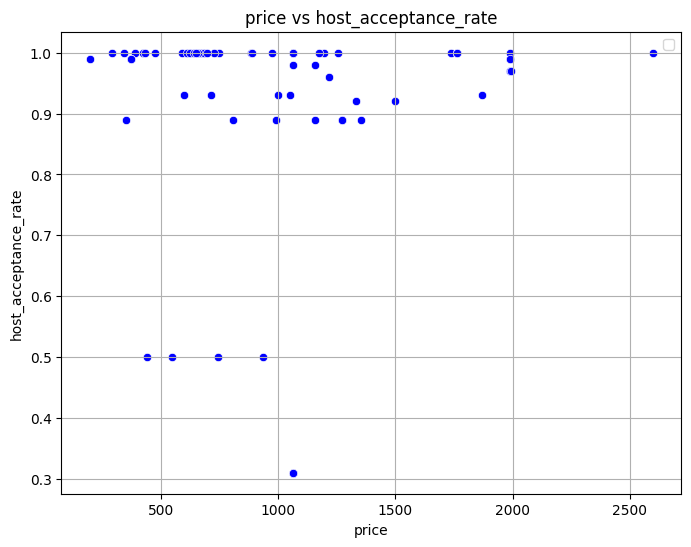

In [7]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='host_acceptance_rate', x='price',  color = 'blue', data=df)
plt.title('price vs host_acceptance_rate')
plt.xlabel('price')
plt.ylabel('host_acceptance_rate')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
indep= df[['host_acceptance_rate']]
dep = df[['price']]

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [10]:
model.fit(indep, dep)

LinearRegression()

In [11]:
type(model)

sklearn.linear_model._base.LinearRegression

In [12]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_acceptance_rate'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[183.92770024]]),
 'rank_': 1,
 'singular_': array([1.60672581]),
 'intercept_': array([860.63211666])}

In [13]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[183.92770024]]
Intercepto: [860.63211666]
y = [183.92770024]x + [860.63211666]


In [14]:
r2 = model.score(indep, dep)
r2

0.004804918363333965

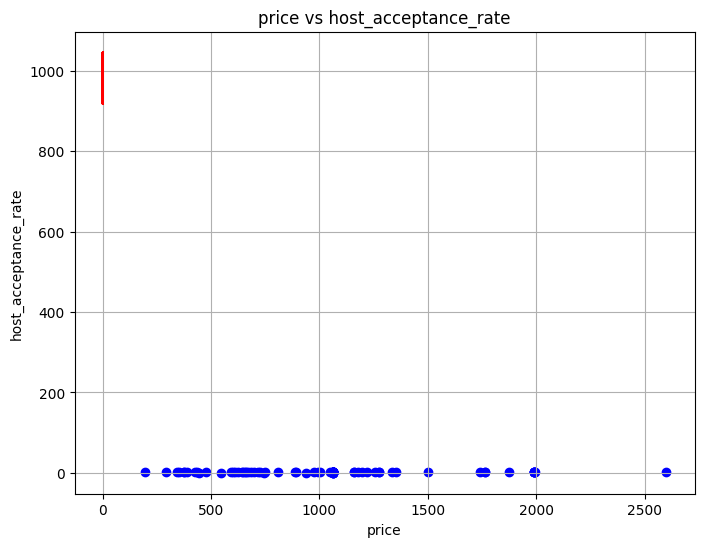

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs host_acceptance_rate')
plt.xlabel('price')
plt.ylabel('host_acceptance_rate')
plt.grid(True)
plt.show()

In [16]:
yPred = model.predict(df[['host_acceptance_rate']])
yPred

array([[1031.68487788],
       [1029.84560088],
       [1029.84560088],
       [1031.68487788],
       [1024.32776987],
       [1024.32776987],
       [1024.32776987],
       [1024.32776987],
       [1040.88126289],
       [ 917.64970374],
       [1037.20270889],
       [1040.88126289],
       [ 917.64970374],
       [ 917.64970374],
       [1044.5598169 ],
       [1044.5598169 ],
       [1024.32776987],
       [ 917.64970374],
       [1044.5598169 ],
       [1042.7205399 ],
       [1039.04198589],
       [1044.5598169 ],
       [1042.7205399 ],
       [1039.04198589],
       [1044.5598169 ],
       [1024.32776987],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1044.5598169 ],
       [1031.68487788],
       [1044.559

In [17]:
df['Predicciones'] = yPred
df.head()

C:\Users\issei\AppData\Local\Temp\ipykernel_39244\926117882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Predicciones'] = yPred


,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
47,48,281134,196253,1,1,previous scrape,COOL PENT HOUSE APARTMENT @CONDESA,Amazing Pent House apartment in the heart fo C...,No neighborhood_overview,Fernando,...,0.0,4.71,4.71,5.00,5.00,5.00,5.00,4.86,0.06,1031.684878
61,62,1565220,2518152,1,1,previous scrape,Descansa en la Suite de la Abuelita San Angel ...,"Beautiful, spacious and calm independent Suite...",San Ángel is a XVI century village nestled in ...,Martha Laura,...,0.0,4.96,5.00,5.00,5.00,4.96,4.93,4.93,0.21,1029.845601
74,75,1736063,2518152,1,1,previous scrape,"Cómodo Estudio del Botánico, San Angel CDMX","Small, very practical and beautiful independen...",San Ángel is a XVI century village nestled in ...,Martha Laura,...,0.0,4.88,4.84,4.97,4.89,4.93,4.96,4.86,0.45,1029.845601
99,100,571166,196253,1,1,city scrape,MODERN/HIP FURNISHED APARTMENT ( S1 Condesa Haus),This is a one bedroom furnished apartment in t...,No neighborhood_overview,Fernando,...,0.0,4.00,5.00,5.00,5.00,4.90,5.00,4.00,0.01,1031.684878
134,135,737328,3850198,1,1,city scrape,Business Suite BEIGE near Reforma,No description,The area in which our service is located stand...,Hermann,...,0.0,4.84,4.88,4.84,5.00,5.00,4.84,4.80,0.18,1024.327770


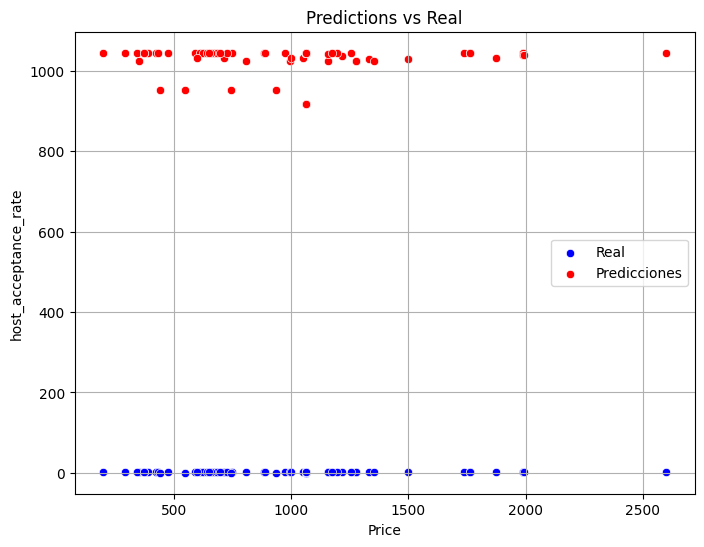

In [18]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='host_acceptance_rate', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('host_acceptance_rate')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
coefDe = model.score(indep, dep)
coefDe

0.004804918363333965

In [20]:
coefCo = np.sqrt(coefDe)
coefCo

0.06931751844471905